In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import f_classif,chi2
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,LabelEncoder

Task 1 : 
   Data Preparation
         ---- Load the dataset

In [291]:
df=pd.read_csv('heart_disease_synthetic.csv')

In [303]:
df.shape

(20, 13)

Task 2:
   Exploratory Data Analysis(EDA): 
        --- missing  values
        --- duplicates
        --- outliers
        --- inconsistant 
        --- features distribution and correlation matrix

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       20 non-null     int64  
 1   Gender    20 non-null     object 
 2   cp        20 non-null     object 
 3   trestbps  20 non-null     int64  
 4   chol      20 non-null     int64  
 5   fbs       20 non-null     int64  
 6   restecg   20 non-null     int64  
 7   thalch    20 non-null     int64  
 8   exang     20 non-null     int64  
 9   oldpeak   20 non-null     float64
 10  slope     20 non-null     int64  
 11  thal      20 non-null     int64  
 12  num       20 non-null     object 
dtypes: float64(1), int64(9), object(3)
memory usage: 2.2+ KB


In [293]:
###  checking missing values
df.isnull().sum()

age         0
Gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [294]:
#### finding duplicates
df.duplicated().sum()

np.int64(0)

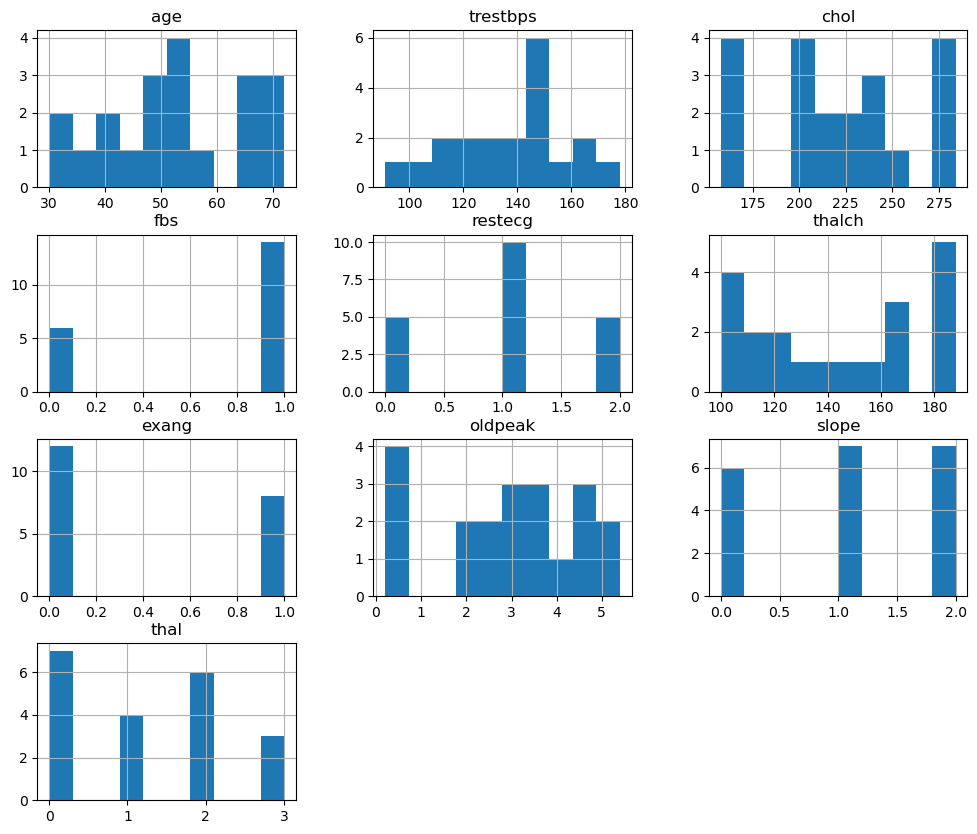

In [295]:
### histogram plots
df.hist(figsize=(12,10))
plt.show()

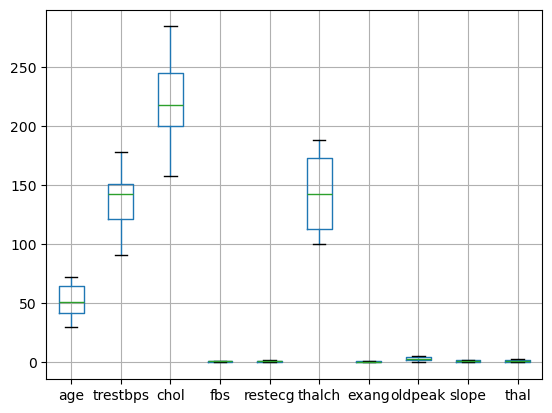

In [296]:
#### boxplots
df.boxplot()
plt.show()

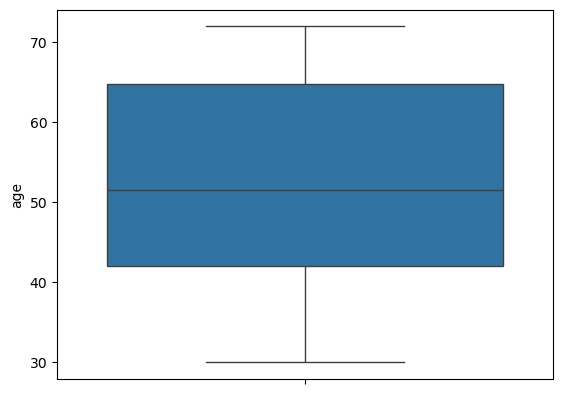

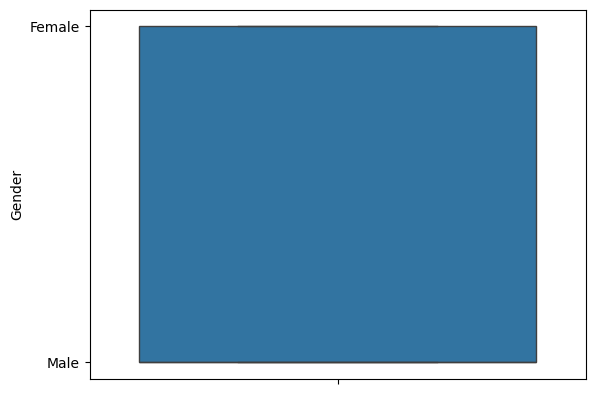

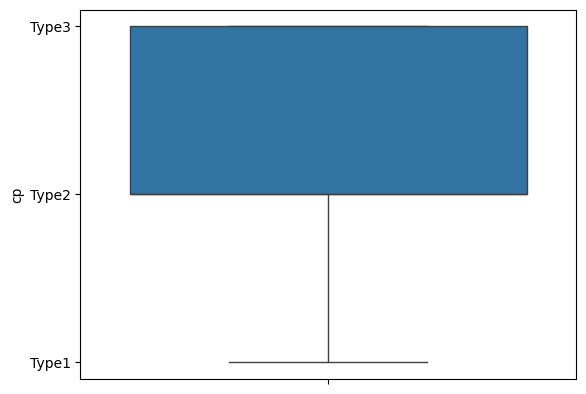

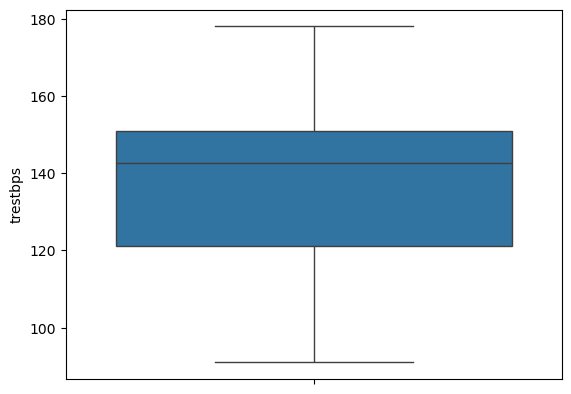

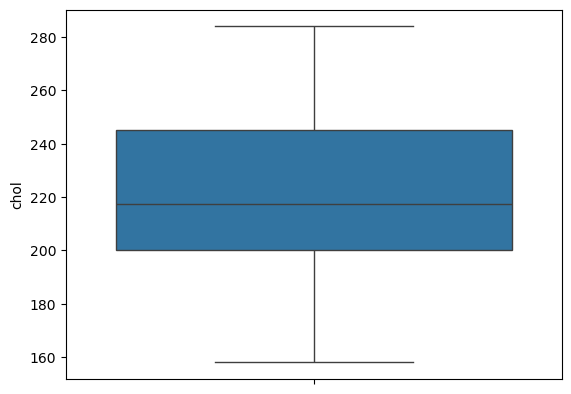

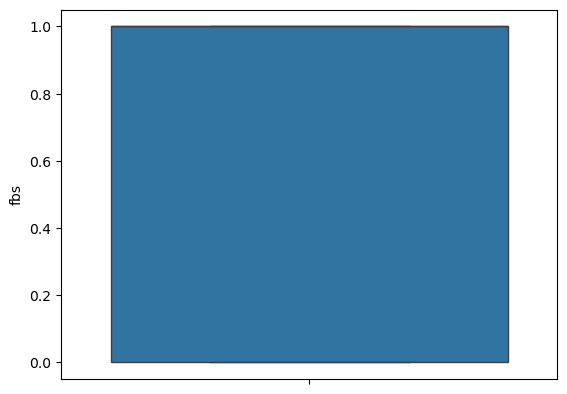

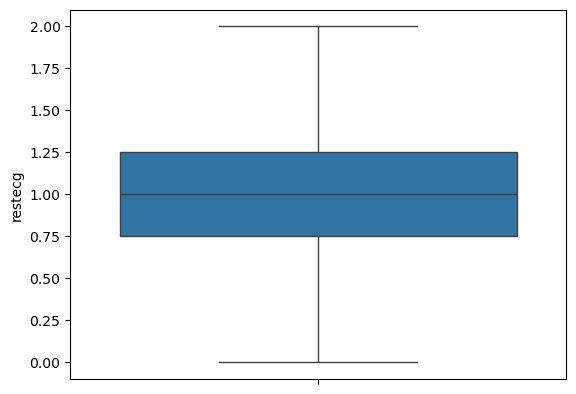

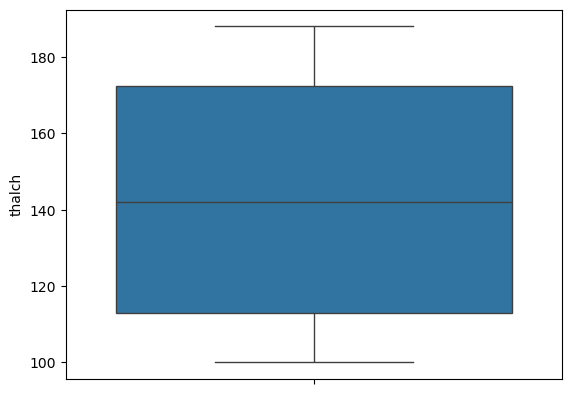

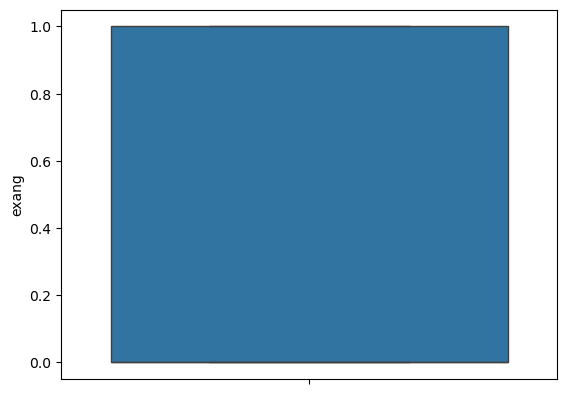

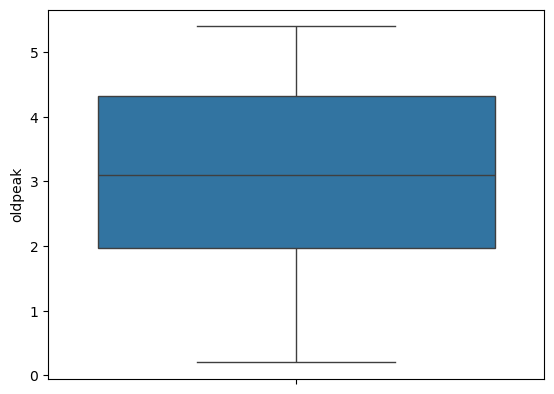

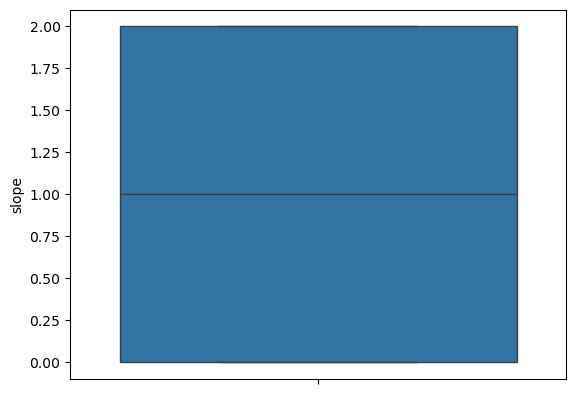

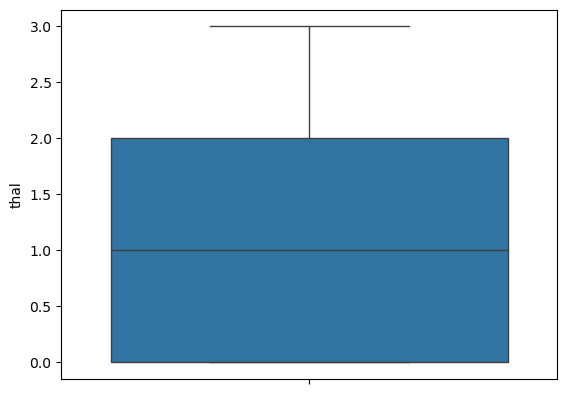

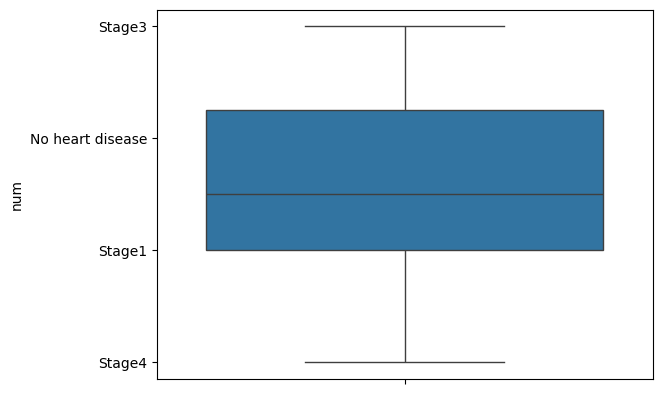

In [297]:
#### checking outliers
for col in df.columns:
    sns.boxplot(data=df,y=col) 
    plt.show()

task 3: 
    Feature Engineering: 
       ----encoding technique
       ----scaling technique
       ----handle missing values

feature selection

In [298]:
target=df[['num']] 
features=df.drop(columns=['num'])

In [299]:
target.head()

,num
0,Stage3
1,No heart disease
2,Stage1
3,Stage1
4,No heart disease


In [253]:
features.head()

,age,Gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,67,Female,Type3,119,200,0,1,123,0,2.0,2,2
1,57,Male,Type3,127,257,1,0,125,0,4.4,2,3
2,43,Male,Type2,91,204,0,2,188,0,3.8,0,1
3,71,Male,Type1,153,213,1,1,159,0,5.3,2,2
4,36,Female,Type3,149,280,0,1,140,0,2.8,2,3


In [302]:
target.shape

(20, 1)

scaling techniques for continuous numerical columns

In [255]:
### standard scaling
std_sca=StandardScaler()

In [256]:
features[['age','trestbps','chol','thalch']]=std_sca.fit_transform(features[['age','trestbps','chol','thalch']])

In [257]:
### ordinal encoder scaling
ord_enc=OrdinalEncoder() 
features[['cp']]=ord_enc.fit_transform(features[['cp']])

In [258]:
features.head()

,age,Gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,1.184000,Female,2.0,-0.827639,-0.554894,0,1,-0.688654,0,-0.623530,2,2
1,0.402482,Male,2.0,-0.468771,0.882786,1,0,-0.624742,0,0.888058,2,3
2,-0.691644,Male,1.0,-2.083677,-0.454004,0,2,1.388493,0,0.510161,0,1
3,1.496608,Male,0.0,0.697550,-0.227002,1,1,0.461766,0,1.454903,2,2
4,-1.238707,Female,2.0,0.518116,1.462903,0,1,-0.145400,0,-0.119667,2,3


encoding technique for target categorical columns

In [259]:
### label encoding
target1=target.copy() 
lab_enc=LabelEncoder()

In [260]:
target1=lab_enc.fit_transform(target1) 
target1=pd.DataFrame(target1,columns=target.columns) 
target1.head()

,num
0,2
1,0
2,1
3,1
4,0


task 4: 
   decision Tree Classification:
                    ----splits dataset into training and testing 
                    ----model building 
                    ----trains the model

In [261]:
#### spliting dataset into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(features,target1,train_size=0.8,random_state=100)
print(x_train.shape) 
print(x_test.shape) 
print(y_train.shape) 
print(y_test.shape)

(16, 12)
(4, 12)
(16, 1)
(4, 1)


In [262]:
x_train.head()

,age,Gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
13,1.262152,Male,2.0,-0.289337,-1.488125,1,0,-1.423644,1,-1.757221,0,0
6,1.184000,Female,0.0,-0.693064,1.563793,0,1,-0.976259,0,0.825075,0,2
16,-0.144581,Male,2.0,-1.500517,-0.504449,1,0,0.557634,1,0.510161,0,0
1,0.402482,Male,2.0,-0.468771,0.882786,1,0,-0.624742,0,0.888058,2,3
9,-1.004251,Male,1.0,-1.186507,-1.387236,0,2,1.388493,1,1.014024,2,0


In [263]:
x_train=pd.get_dummies(x_train,dtype='int')

In [264]:
x_test=pd.get_dummies(x_test,dtype='int')

In [265]:
x_train.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,Gender_Female,Gender_Male
13,1.262152,2.0,-0.289337,-1.488125,1,0,-1.423644,1,-1.757221,0,0,0,1
6,1.184000,0.0,-0.693064,1.563793,0,1,-0.976259,0,0.825075,0,2,1,0
16,-0.144581,2.0,-1.500517,-0.504449,1,0,0.557634,1,0.510161,0,0,0,1
1,0.402482,2.0,-0.468771,0.882786,1,0,-0.624742,0,0.888058,2,3,0,1
9,-1.004251,1.0,-1.186507,-1.387236,0,2,1.388493,1,1.014024,2,0,0,1


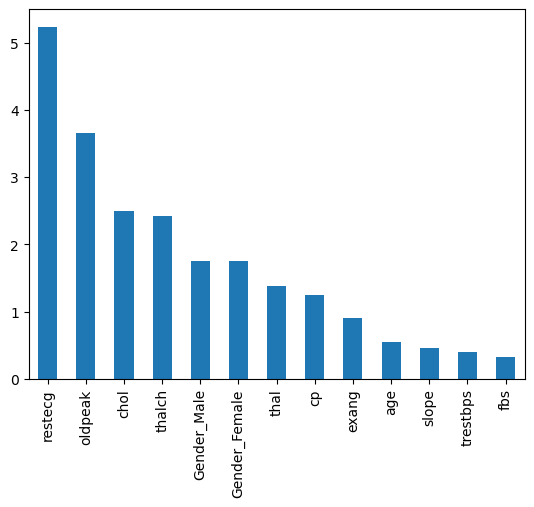

In [266]:
### feature selection
f_clas= f_classif(x_train,y_train)
pd.Series(f_clas[0],index=x_train.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

x_train.drop(columns=['slope','trestbps','fbs'],inplace=True)
x_test.drop(columns=['slope','trestbps','fbs'],inplace=True)


In [267]:
x_train.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,Gender_Female,Gender_Male
13,1.262152,2.0,-0.289337,-1.488125,1,0,-1.423644,1,-1.757221,0,0,0,1
6,1.184000,0.0,-0.693064,1.563793,0,1,-0.976259,0,0.825075,0,2,1,0
16,-0.144581,2.0,-1.500517,-0.504449,1,0,0.557634,1,0.510161,0,0,0,1
1,0.402482,2.0,-0.468771,0.882786,1,0,-0.624742,0,0.888058,2,3,0,1
9,-1.004251,1.0,-1.186507,-1.387236,0,2,1.388493,1,1.014024,2,0,0,1


In [268]:
x_train['Gender'] = LabelEncoder().fit_transform(x_train[['Gender_Female','Gender_Male']].idxmax(axis=1))
x_test['Gender'] = LabelEncoder().fit_transform(x_test[['Gender_Female','Gender_Male']].idxmax(axis=1))
x_train['cp']=x_train['cp'].astype(int)
x_test['cp']=x_test['cp'].astype(int)
x_train.drop(columns=['Gender_Female','Gender_Male'],inplace=True)
x_test.drop(columns=['Gender_Female','Gender_Male'],inplace=True)

In [269]:
x_test.head()

,age,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,Gender
17,-1.707618,1,0.607833,1.437681,1,1,-1.104083,0,-0.686513,1,2,0
19,1.574759,1,-0.065045,0.479227,1,0,-1.199952,1,1.517886,1,1,1
11,0.011723,2,0.024672,0.403559,1,1,-1.167995,0,0.069281,1,2,0
18,0.011723,2,0.607833,0.277447,1,2,1.132844,0,0.069281,1,2,0


In [271]:
dec_tree=DecisionTreeClassifier(criterion='entropy',splitter='random',max_depth=5,random_state=50) 
dec_tree.fit(x_train,y_train) 
y_pred=dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.25

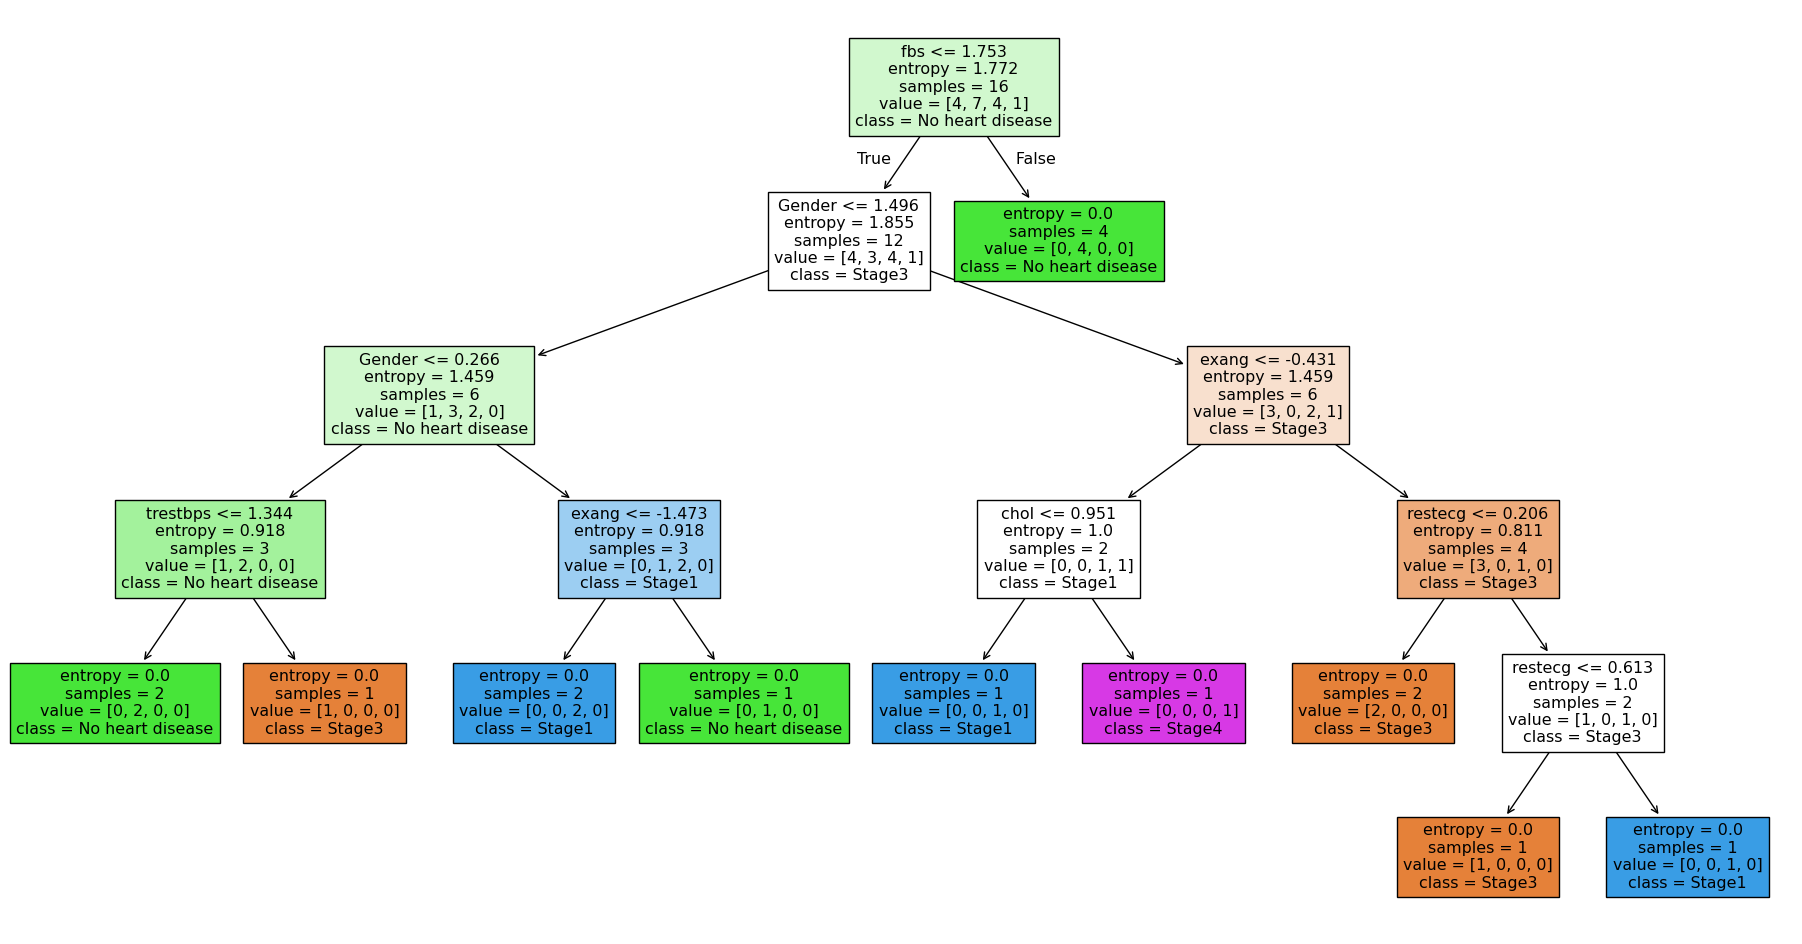

In [272]:
#### Plotting the Decision Tree
plt.figure(figsize=(23,12))
plot_tree(dec_tree,filled=True,feature_names=list(features),class_names=target.num.unique());
plt.show()

In [273]:
### grid sGridSearchCV
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,8)}

In [274]:
grid_search=GridSearchCV(estimator=dec_tree,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_,grid_search.best_score_

({'criterion': 'gini', 'max_depth': 4, 'splitter': 'random'},
 np.float64(0.4333333333333333))

In [278]:
dec_tree=DecisionTreeClassifier(criterion='entropy',splitter='random',max_depth=4,random_state=50) 
dec_tree.fit(x_train,y_train) 
y_pred=dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.25

In [279]:
### bagging 
from sklearn.ensemble import BaggingClassifier 
from sklearn.linear_model import LogisticRegression 


In [280]:
bag_class=BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=3),n_estimators=200,bootstrap_features=True,bootstrap=True,max_features=0.7,max_samples=0.8,random_state=50)

In [281]:
bag_class.fit(x_train,y_train) 
y_pred=bag_class.predict(x_test) 
accuracy_score(y_test,y_pred)

0.5

In [287]:
bag_class=BaggingClassifier(estimator=LogisticRegression(),n_estimators=100,bootstrap_features=True,bootstrap=True,max_features=0.7,max_samples=0.8,random_state=50)

In [288]:
bag_class.fit(x_train,y_train) 
y_pred=bag_class.predict(x_test) 
accuracy_score(y_test,y_pred)

0.0

In [284]:
#### grid seach 
params={'n_estimators':[50,100,150,200],'max_features':[0.5,0.6,0.7,0.8]}

In [285]:
grid_search=GridSearchCV(estimator=bag_class,param_grid=params,cv=5) 
grid_search.fit(x_train,y_train) 
grid_search.best_params_,grid_search.best_score_

({'max_features': 0.5, 'n_estimators': 50}, np.float64(0.5))

In [286]:
bag_class=BaggingClassifier(estimator=LogisticRegression(),n_estimators=50,bootstrap_features=True,bootstrap=True,max_features=0.5,max_samples=0.8,random_state=50) 
bag_class.fit(x_train,y_train) 
y_pred=bag_class.predict(x_test) 
accuracy_score(y_test,y_pred)

0.5

Interview questions and answers

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
   
     -- max_depth:

            -prevents overfitting

     -- min_sample_split:

            -higher values --> simple tree,less overfitting

     -- min_sample_leaf:

            -ensures leaves have enough data, improves generalization

     -- max_features:

            -reduces variance,increase bias if too small

     --ccp_alpha:

            -help balance bias-variance trade-off

     --criterion:

          -choice affects how splits are made

2. What is the difference between the Label encoding and One-hot encoding?
   
  ---label encoding is compact but can trick the model into thinkinh categories have a ranking

  ---one-hot encoding is safer for unordered categories but can blow up the dataset size if there are many unique values